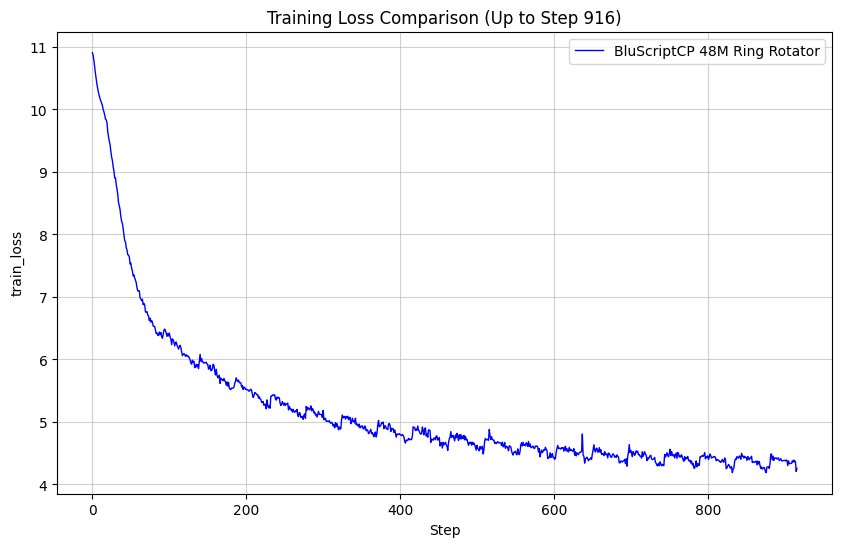

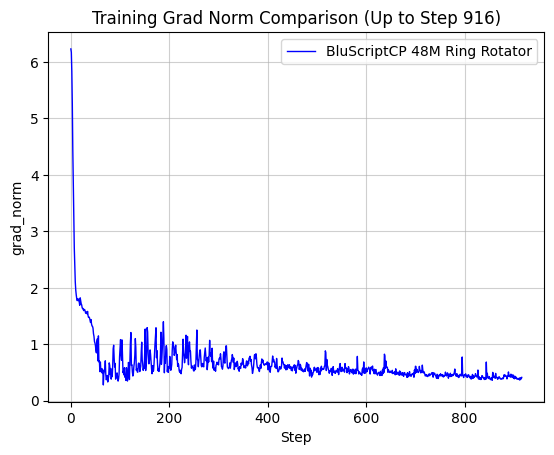

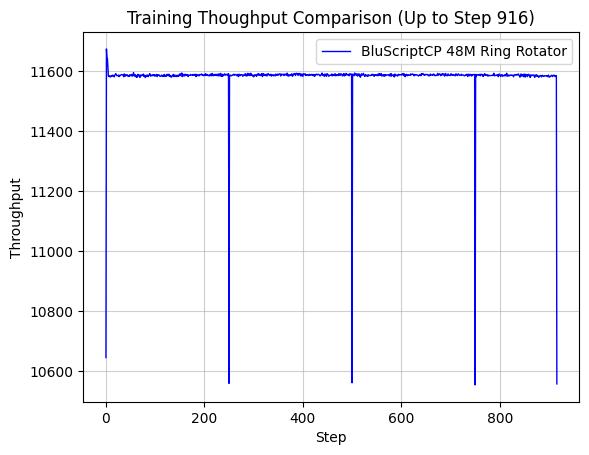

Max. Throughput BluScriptCP 48M Ring Rotator: 11674.623382
Avg. Throughput BluScriptCP 48M Ring Rotator: 11582.07168025736
Min Train Loss BluScriptCP 48M Ring Rotator: 4.187034
Min Val Loss BluScriptCP 48M Ring Rotator: 4.342005
Avg. Time BluScriptCP 48M Ring Rotator: 45269.26466228026
Avg. Data Time BluScriptCP 48M Ring Rotator: 8.928428597600872
Avg. Forward Time BluScriptCP 48M Ring Rotator: 13955.531257437297
Avg. Loss Time BluScriptCP 48M Ring Rotator: 156.2313310883315
Avg. Backward Time BluScriptCP 48M Ring Rotator: 31112.237717525626


In [3]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log1.csv')
# df_old = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/Pytorch/Pytorch_CP_AttnStyle_FP32_Training_logs/Pytorch_CP_AttnStyle_FP32_Training_log41.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    # df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
# df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['train_loss'], label='BluScriptCP 48M Ring Rotator', linewidth=1, color = 'blue')
# # plt.plot(df_old_truncated['step'], df_old_truncated['train_loss'], label='Pytorch CP run (161M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['train_loss'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('train_loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='BluScriptCP 48M Ring Rotator', linewidth=1, color = 'blue')
# # plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Pytorch CP run (161M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='BluScriptCP 48M Ring Rotator', linewidth=1, color = 'blue')
# # plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Pytorch CP run (161M)',linewidth=1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput BluScriptCP 48M Ring Rotator:",df_new['tok_per_sec'].max())
print("Avg. Throughput BluScriptCP 48M Ring Rotator:",df_new['tok_per_sec'].mean())
print("Min Train Loss BluScriptCP 48M Ring Rotator:",df_new['train_loss'][:].min())
print("Min Val Loss BluScriptCP 48M Ring Rotator:",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time BluScriptCP 48M Ring Rotator:",df_new['dt_ms'].mean())
print("Avg. Data Time BluScriptCP 48M Ring Rotator:",df_new['timer_data'][:].mean())
print("Avg. Forward Time BluScriptCP 48M Ring Rotator:",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time BluScriptCP 48M Ring Rotator:",df_new['timer_loss'][:].mean())
print("Avg. Backward Time BluScriptCP 48M Ring Rotator:",df_new['timer_bwd'][:].mean())
# print("Avg. Attention Time BluScriptCP 48M Ring Rotator:",df_new['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time BluScriptCP 48M Ring Rotator:",df_new['timer_clip'][:].mean())
# print("Avg. Optimizer Time BluScriptCP 48M Ring Rotator:",df_new['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time BluScriptCP 48M Ring Rotator:",df_new['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time BluScriptCP 48M Ring Rotator:",df_new['timer_pos_emb'].mean())
# print("Avg. Mlp Time BluScriptCP 48M Ring Rotator:",df_new['timer_mlp'][:].mean())
# print("Avg. Ln_f Time BluScriptCP 48M Ring Rotator:",df_new['timer_ln_f'][:].mean())
# print("Avg. LM Head Time BluScriptCP 48M Ring Rotator:",df_new['timer_lm_head'][:].mean())


# print("\nMax. Throughput Pytorch CP run (161M):",df_old_truncated['tok_per_sec'].max())
# print("Avg. Throughput Pytorch CP run (161M):",df_old_truncated['tok_per_sec'].mean())
# print("Min Train Loss Pytorch CP run (161M):",df_old_truncated['train_loss'][:].min())
# # print("Min Val Loss Pytorch CP run (161M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Pytorch CP run (161M):",df_old_truncated['dt_ms'].mean())
# print("Avg. Data Time Pytorch CP run (161M):",df_old_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Pytorch CP run (161M):",df_old_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Pytorch CP run (161M):",df_old_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Pytorch CP run (161M):",df_old_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time Pytorch CP run (161M):",df_old_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time Pytorch CP run (161M):",df_old_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time Pytorch CP run (161M):",df_old_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time Pytorch CP run (161M):",df_old_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time Pytorch CP run (161M):",df_old_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time Pytorch CP run (161M):",df_old_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time Pytorch CP run (161M):",df_old_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time Pytorch CP run (161M):",df_old_truncated['timer_lm_head'][:].mean())



# print("\nMax. Throughput Our CP run before (161M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput Our CP run before (161M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss Our CP run before (161M):",df_3rd_truncated['train_loss'][:].min())
# # print("Min Val Loss Our CP run before (161M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Our CP run before (161M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time Our CP run before (161M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Our CP run before (161M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Our CP run before (161M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Our CP run before (161M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time Our CP run before (161M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time Our CP run before (161M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time Our CP run before (161M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time Our CP run before (161M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time Our CP run before (161M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time Our CP run before (161M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time Our CP run before (161M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time Our CP run before (161M):",df_3rd_truncated['timer_lm_head'][:].mean())